In [ ]:
# 1) Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy import stats


In [ ]:
df = pd.read_csv('duracion.csv')
df

,Temperatura,TipoCarga,Duracion_h
0,Baja,Estándar,39
1,Baja,Estándar,36
2,Baja,Rápida,43
3,Baja,Rápida,37
4,Baja,Turbo,37
5,Baja,Turbo,41
6,Media,Estándar,41
7,Media,Estándar,35
8,Media,Rápida,42
9,Media,Rápida,39


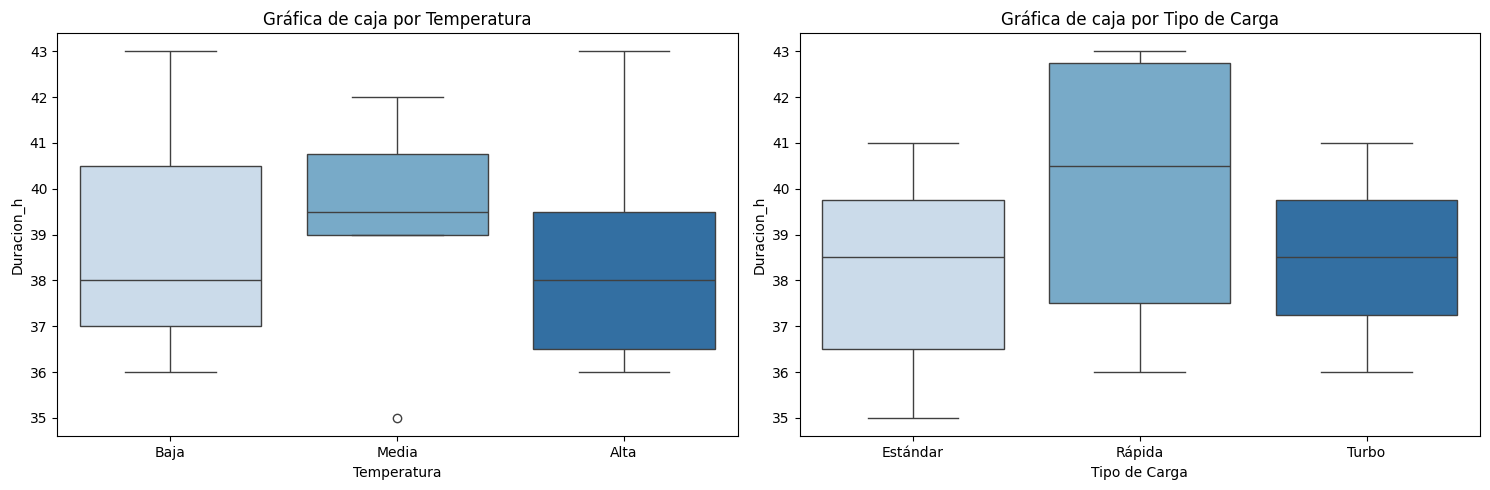

In [ ]:
# 3) Boxplots
fig, axs = plt.subplots(ncols=2, figsize=(15, 5))

sns.boxplot(x='Temperatura', y='Duracion_h', hue='Temperatura', data=df, palette='Blues', orient='v', ax=axs[0])
axs[0].set_title('Gráfica de caja por Temperatura')
axs[0].set_xlabel("Temperatura")
axs[0].set_ylabel("Duracion_h")

sns.boxplot(x='TipoCarga', y='Duracion_h', hue='TipoCarga', data=df, palette='Blues', orient='v', ax=axs[1])
axs[1].set_title('Gráfica de caja por Tipo de Carga')
axs[1].set_xlabel("Tipo de Carga")
axs[1].set_ylabel("Duracion_h")

plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('Duracion_h ~ C(Temperatura) + C(TipoCarga) + C(Temperatura):C(TipoCarga)', data=df).fit()
aov_table = sm.stats.anova_lm(model, typ=2)

print(aov_table)

                                sum_sq   df         F    PR(>F)
C(Temperatura)                2.111111  2.0  0.115854  0.891912
C(TipoCarga)                 11.444444  2.0  0.628049  0.555484
C(Temperatura):C(TipoCarga)   8.222222  4.0  0.225610  0.917278
Residual                     82.000000  9.0       NaN       NaN


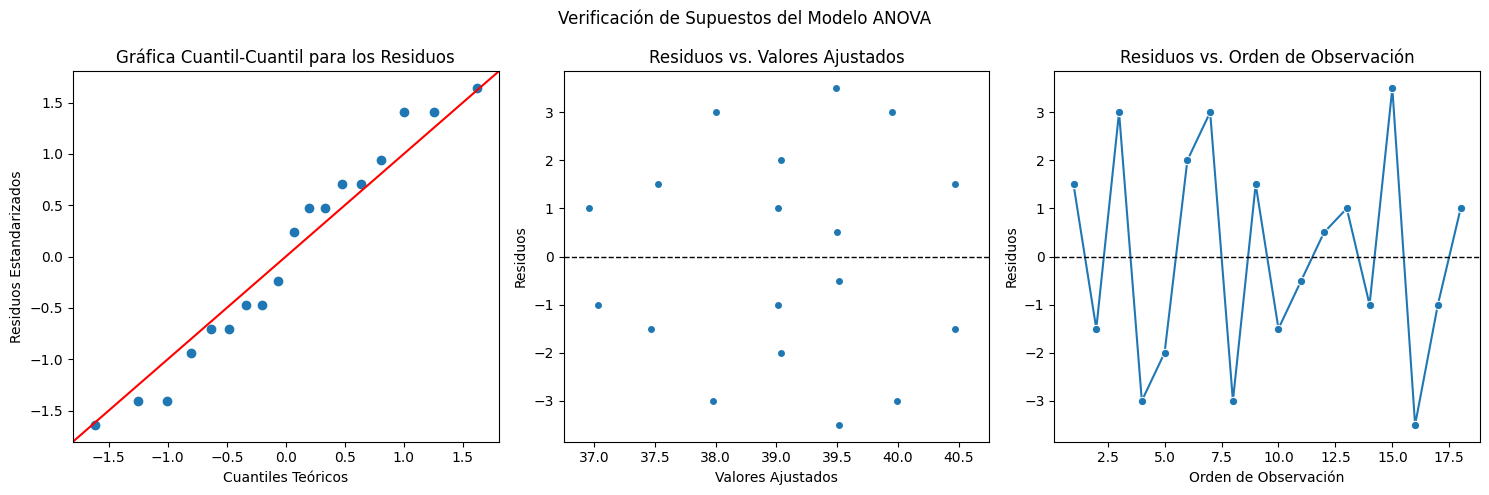

In [ ]:
# Verificación de Supuestos
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 1. Normalidad de los residuos: Gráfico Cuantil-Cuantil (Q-Q Plot)
# Si los puntos se alinean aproximadamente a lo largo de la línea recta, los residuos son aproximadamente normales.
fig, axs = plt.subplots(ncols=3,figsize=(15,5))

res = model.resid
sm.qqplot(res,fit=True ,line='45',ax=axs[0])
axs[0].set_title('Gráfica Cuantil-Cuantil para los Residuos')
axs[0].set_xlabel("Cuantiles Teóricos")
axs[0].set_ylabel("Residuos Estandarizados")


# 2. Homogeneidad de la varianza (Homocedasticidad): Gráfico de Residuos vs. Valores Ajustados
# Si los puntos se distribuyen aleatoriamente alrededor de la línea horizontal y no muestran un patrón (por ejemplo, forma de cono), se cumple el supuesto.
adj = model.fittedvalues.round(2)
sns.stripplot(x=adj,y=res,ax=axs[1])
axs[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axs[1].set_ylabel('Residuos')
axs[1].set_xlabel('Valores Ajustados')
axs[1].set_title('Residuos vs. Valores Ajustados')

# 3. Independencia de los residuos: Gráfico de Residuos vs. Orden de Observación
# Si no hay patrones o tendencias evidentes en este gráfico, sugiere que los residuos son independientes.
sns.lineplot(x=res.index+1,y=res,marker='o',ax=axs[2])
axs[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
axs[2].set_title('Residuos vs. Orden de Observación')
axs[2].set_xlabel('Orden de Observación')
axs[2].set_ylabel('Residuos')

fig.suptitle('Verificación de Supuestos del Modelo ANOVA')

plt.tight_layout()
plt.show()

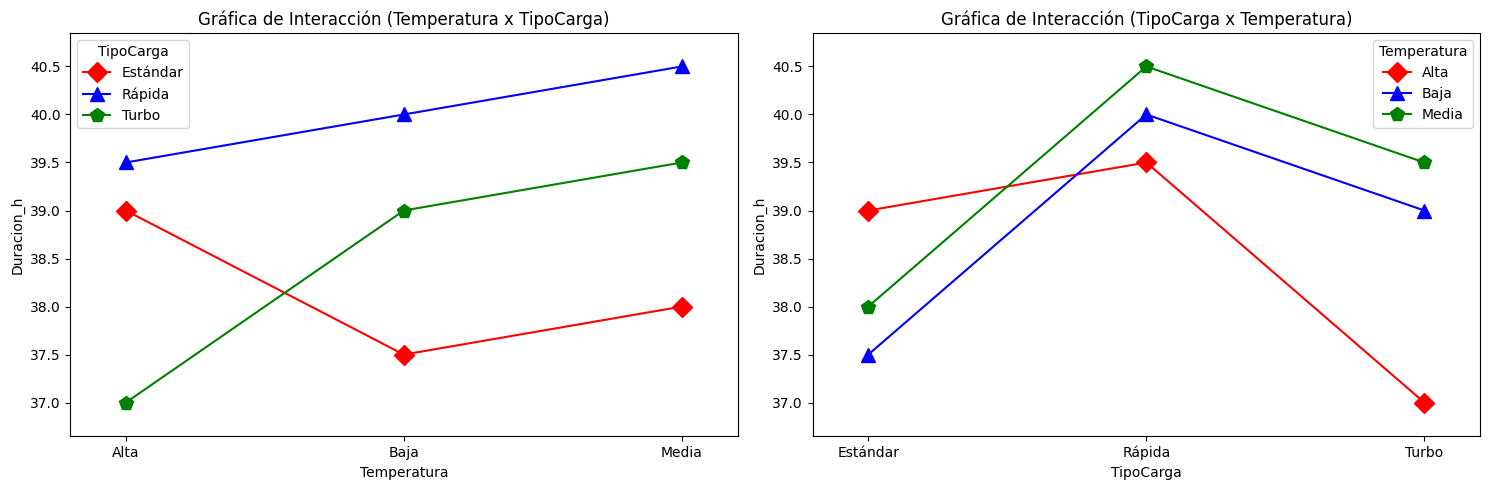

In [ ]:
from statsmodels.graphics.factorplots import interaction_plot

fig, axs = plt.subplots(ncols=2, figsize=(15, 5))

fig = interaction_plot(x=df.Temperatura,
    trace=df.TipoCarga,
    response=df.Duracion_h,
    colors=["red", "blue","green"],
    markers=["D", "^","p"],
    ms=10,ax=axs[0])
axs[0].set_title('Gráfica de Interacción (Temperatura x TipoCarga)')
axs[0].set_xlabel("Temperatura")
axs[0].set_ylabel("Duracion_h")

fig = interaction_plot(x=df.TipoCarga,
    trace=df.Temperatura,
    response=df.Duracion_h,
    colors=["red", "blue","green"],
    markers=["D", "^","p"],
    ms=10,ax=axs[1])
axs[1].set_title('Gráfica de Interacción (TipoCarga x Temperatura)')
axs[1].set_xlabel("TipoCarga")
axs[1].set_ylabel("Duracion_h")

plt.tight_layout()
plt.show()